# 04 · SODAs — discovering the full Differential-Algebraic system

The Michaelis–Menten mechanism

$$E + S \;\underset{k_r}{\overset{k}{\rightleftharpoons}}\; ES \;\xrightarrow{k_{cat}}\; E + P$$

is, under quasi-steady state, a **DAE**: differential laws for the dynamic species *plus*
algebraic constraints linking all four. With $k=k_r=k_{cat}=1$ and total enzyme $E_0=1$, the
**true system** is

$$
\textbf{differential:}\quad \dot{[S]} = -[ES], \qquad \dot{[P]} = +[ES] \\
\textbf{algebraic:}\quad [E]+[ES]=1 \;\;(\text{enzyme conservation}), \qquad
[S][E]=2\,[ES] \;\;(\text{QSSA / steady state}).
$$

**SODAs** (Jayadharan et al., *Proc. R. Soc. A* 2026) discovers this in stages: find the
**algebraic relations first**, use them to **refine** (shrink) the candidate library, then find
the **dynamics**. This staged convex approach keeps the recovered model physically structured —
where one-shot regression gets confused by the redundancy the constraints create. We use the
reference implementation, **`DaeFinder`**.

In [1]:
# --- Environment setup (kept INACTIVE on purpose) -------------------------
# Uncomment the next line the first time you run these notebooks to install
# every dependency (pysindy, DaeFinder, cvxpy, ...). Left commented so the
# notebook never reinstalls packages while you teach from it.
# !pip install -r ../requirements.txt

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path: sys.path.insert(0, cand)
            return cand
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Data: a Michaelis–Menten enzyme assay (multiple substrate levels)

Like a real enzyme assay, we run the **same enzyme** ($E_0=1$, fixed rates) at **several
initial substrate concentrations** $S_0$. This matters: a *single* trajectory admits many
spurious algebraic relations, but the **true** relations are the ones that hold across **all**
trajectories. The QSSA relation is initial-condition–independent, and enzyme conservation
shares the same $E_0$ — so both become identifiable, while substrate totals (which differ per
run) are correctly *not* flagged as universal.

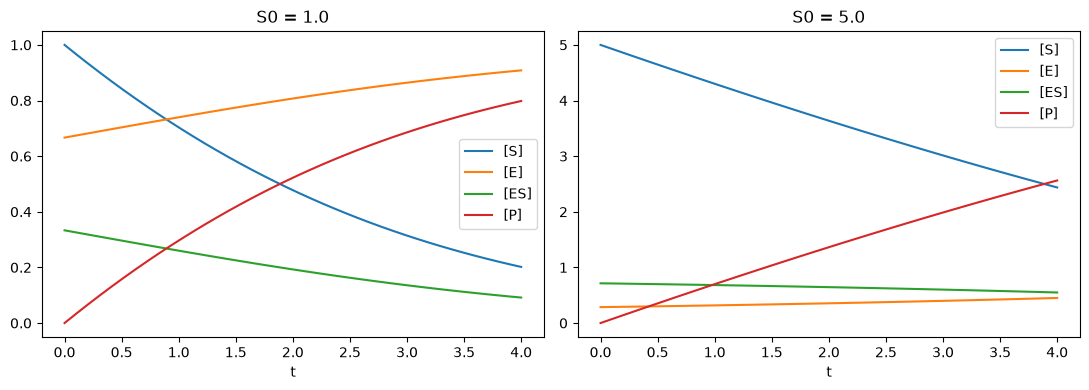

In [3]:
import pandas as pd
from daeFinder import (solveMM, smooth_data, PolyFeatureMatrix,
                       AlgModelFinder, sequentialThLin,
                       get_refined_lib, remove_paranth_from_feat)

k_rates = pd.Series({"k": 1.0, "kr": 1.0, "kcat": 1.0})
S0_list = [1.0, 2.0, 3.0, 4.0, 5.0]
species = ["[S]", "[E]", "[ES]", "[P]"]
tg = np.linspace(0, 4, 40)

raw_list, smooth_list = [], []
for S0 in S0_list:
    IC = pd.Series({"S": S0, "P": 0.0, "E": 1.0})
    df = pd.DataFrame(solveMM(IC, k_rates, tg, "demo"), columns=species)
    df["[t]"] = tg
    raw_list.append(df)
    # smooth each trajectory separately and get derivatives (d([P]) /dt, ...)
    smooth_list.append(smooth_data(df, domain_var="[t]", derr_order=1,
                                   noise_perc=0, eval_points=tg))
smooth_app = pd.concat(smooth_list, ignore_index=True)
state = smooth_app[species]            # smoothed state columns only

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for j, S0 in [(0, S0_list[0]), (-1, S0_list[-1])]:
    for c in species:
        ax[0 if j == 0 else 1].plot(tg, raw_list[j][c], label=c)
    ax[0 if j == 0 else 1].set_title(f"S0 = {S0}"); ax[0 if j == 0 else 1].legend(); ax[0 if j == 0 else 1].set_xlabel("t")
plt.tight_layout(); plt.show()

## Candidate library (degree 3)

Polynomial features up to degree 3 — rich enough to contain the quadratic QSSA term $[S][E]$
and beyond. We drop the constant `1` column (an intercept is fit instead).

In [4]:
data_df = state.copy()
import sympy
# Sympy symbols whose names exactly match the state columns ("[S]","[E]","[ES]","[P]").
# get_refined_lib() rebuilds the same symbols internally from the column names, so passing
# these lets it symbolically drop every library term containing a given factor.
S, E, ES, P = sympy.symbols(list(data_df.columns))

lib_full = PolyFeatureMatrix(degree=3).fit_transform(state).drop(["1"], axis=1)
print("library terms (%d):" % lib_full.shape[1], list(lib_full.columns))

library terms (34): ['[S]', '[E]', '[ES]', '[P]', '[S]^2', '[S] [E]', '[S] [ES]', '[S] [P]', '[E]^2', '[E] [ES]', '[E] [P]', '[ES]^2', '[ES] [P]', '[P]^2', '[S]^3', '[S]^2 [E]', '[S]^2 [ES]', '[S]^2 [P]', '[S] [E]^2', '[S] [E] [ES]', '[S] [E] [P]', '[S] [ES]^2', '[S] [ES] [P]', '[S] [P]^2', '[E]^3', '[E]^2 [ES]', '[E]^2 [P]', '[E] [ES]^2', '[E] [ES] [P]', '[E] [P]^2', '[ES]^3', '[ES]^2 [P]', '[ES] [P]^2', '[P]^3']


## Step 1 — discover the conservation law

Conservation laws are *linear*, so we run `AlgModelFinder` over the state variables (with an
intercept). The strongest relation (R² ≈ 1) is **enzyme conservation**.

In [5]:
alg1 = AlgModelFinder(model_id="lasso", fit_intercept=True)
alg1.fit(state, scale_columns=True)
print("Best algebraic relations among the states (by R^2):")
print(alg1.best_models(4))

from sklearn.linear_model import LinearRegression
cons = LinearRegression().fit(state[["[ES]"]], state["[E]"])
print("\nEnzyme conservation:  [E] = %.3f [ES] + %.3f"
      % (cons.coef_[0], cons.intercept_), "  =>  [E] + [ES] = %.3f" % cons.intercept_)
print("(Substrate totals differ per run, so [S],[P] show no universal linear law -- correct.)")

Best algebraic relations among the states (by R^2):
             [E]  [ES]           [S]           [P]
[S]        -0.00  0.00           NaN -0.000000e+00
[ES]       -0.90   NaN  1.426738e-15  5.339023e-16
[P]        -0.00  0.00 -0.000000e+00           NaN
[E]          NaN -0.90 -6.255120e+00 -6.046629e-02
r2- metric  0.99  0.99  9.052201e-01  3.477883e-03

Enzyme conservation:  [E] = -1.000 [ES] + 1.000   =>  [E] + [ES] = 1.000
(Substrate totals differ per run, so [S],[P] show no universal linear law -- correct.)


## Step 2 — discover the steady-state (QSSA) relation

The other algebraic relation is quadratic. Fitting $[ES]$ against the product $[S][E]$ recovers
the **quasi-steady-state law** in its recognizable form.

In [6]:
qssa = LinearRegression(fit_intercept=False).fit(lib_full[["[S] [E]"]], lib_full["[ES]"])
print("QSSA (steady state):  [ES] = %.3f [S][E]" % qssa.coef_[0],
      "   <=>   [S][E] = %.1f [ES]" % (1/qssa.coef_[0]),
      "   (R^2 = %.5f)" % qssa.score(lib_full[["[S] [E]"]], lib_full["[ES]"]))

QSSA (steady state):  [ES] = 0.500 [S][E]    <=>   [S][E] = 2.0 [ES]    (R^2 = 1.00000)


## Step 3 — refine the library, then confirm the reduced algebraic relation

Enzyme conservation makes `[E]` **redundant**, so SODAs removes every library term containing
`[E]` with `get_refined_lib`, then searches what remains. The QSSA law re-expressed without
`[E]` is $[S] = 2[ES] + [S][ES]$ (substitute $[E]=1-[ES]$ into $[S][E]=2[ES]$).

In [7]:
dropped_E, refined_lib = get_refined_lib({E}, data_df, lib_full, get_dropped_feat=True)
print("dropped %d terms containing [E], e.g. %s" % (len(dropped_E), sorted(map(str, dropped_E))[:5]))

# Thresholded search on the refined library isolates the substrate equation sparsely.
seq = sequentialThLin(model_id="lasso", coef_threshold=0.1, fit_intercept=False, alpha=0.1)
alg2 = AlgModelFinder(custom_model=True, custom_model_ob=seq)
alg2.fit(refined_lib, scale_columns=True)
s_eq = alg2.best_models()["[S]"]
print("\n[S]-equation, nonzero terms (standardized):")
print(s_eq[s_eq.fillna(0).abs() > 1e-6])

red = LinearRegression(fit_intercept=False).fit(lib_full[["[ES]", "[S] [ES]"]], lib_full["[S]"])
print("\nClean reduced QSSA:  [S] = %.3f [ES] + %.3f [S][ES]   (true 2, 1)" % tuple(red.coef_))

dropped 15 terms containing [E], e.g. ['[E]', '[E] [ES]', '[E] [ES] [P]', '[E] [ES]^2', '[E] [P]']
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 2 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations
Sequential threshold converged in 1 iterations

[S]-equ

## Step 4 — refine again, then discover the dynamics

The QSSA relation also makes the term $[S][ES]$ redundant for the dynamics. After removing
`[E]` **and** `[S][ES]`, the differential equations fall out cleanly.

In [8]:
dropped2, refined_dyn = get_refined_lib({E, S * ES}, data_df, lib_full, get_dropped_feat=True)

for target, truth in [("d([S]) /dt", "-1.0 [ES]"), ("d([P]) /dt", "+1.0 [ES]")]:
    dyn = sequentialThLin(model_id="LR", coef_threshold=0.1, fit_intercept=True)
    dyn.fit(X=refined_dyn, y=smooth_app[target])
    terms = {n: round(float(c), 3) for n, c in zip(dyn.feature_names_in_, dyn.coef_)
             if abs(c) > 1e-2}
    print(f"{target} = {terms}   (true: {truth})")

Sequential threshold converged in 1 iterations
d([S]) /dt = {'[ES]': -1.0}   (true: -1.0 [ES])
Sequential threshold converged in 1 iterations
d([P]) /dt = {'[ES]': 1.0}   (true: +1.0 [ES])


## The full recovered DAE

$$
\boxed{\;\dot{[S]} = -[ES], \qquad \dot{[P]} = +[ES]\;}
\qquad\text{with}\qquad
\boxed{\;[E]+[ES]=1, \qquad [S][E]=2[ES]\;}
$$

Every term matches the ground truth. **Consistency check with notebook 03:** eliminate the
algebraic variables — $[E]=1-[ES]$ and $[S][E]=2[ES]$ give $[ES]=S/(2+S)$ — so
$\dot S = -[ES] = -S/(2+S)$, exactly the rational law SINDy-PI found. SODAs recovered the
*structured* DAE; SINDy-PI recovered its *reduced* rational ODE.

**Takeaway.** By discovering the algebraic constraints first and using them to refine the
library, SODAs untangles the redundancy that constrained (DAE) systems create, recovering both
the conservation/steady-state relations and the dynamics. → `05_benchmark_comparison.ipynb`